<a href="https://colab.research.google.com/github/kiransree2002/Assessment/blob/main/Case_Study_on_Preprocessing_%E2%80%93_Model_Building_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [245]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Loading the data set

In [186]:
#Load the dataset House_Pricing.csv
filepath = "/content/House_Pricing (2).csv"
df_houseprice = pd.read_csv(filepath)

In [187]:
#Display basic information about the dataset using ".info()"
print(df_houseprice.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [188]:
#Display basic information about the dataset using ".describe()"
print(df_houseprice.describe())

                 ID    Sale Price  No of Bedrooms  No of Bathrooms  \
count  2.161300e+04  2.160900e+04    21613.000000     21609.000000   
mean   4.580302e+09  5.401984e+05        3.370842         2.114732   
std    2.876566e+09  3.673890e+05        0.930062         0.770138   
min    1.000102e+06  7.500000e+04        0.000000         0.000000   
25%    2.123049e+09  3.219500e+05        3.000000         1.750000   
50%    3.904930e+09  4.500000e+05        3.000000         2.250000   
75%    7.308900e+09  6.450000e+05        4.000000         2.500000   
max    9.900000e+09  7.700000e+06       33.000000         8.000000   

       Flat Area (in Sqft)  Lot Area (in Sqft)  No of Floors  Overall Grade  \
count         21604.000000        2.160400e+04  21613.000000   21613.000000   
mean           2079.931772        1.510776e+04      1.494309       7.623467   
std             918.487597        4.142827e+04      0.539989       1.105439   
min             290.000000        5.200000e+02      1

#Duplicate Removal

In [189]:
#Rows : Check for duplicate rows in the dataset, if any, and remove them.
df_houseprice.duplicated().sum()
# outputil = np.int64(if any digits present inside this, then -it is the no: of duplicates)

np.int64(0)

In [190]:
#column : Check for duplicate column in the dataset, if any, and remove them.
df_houseprice.T.duplicated().sum()

np.int64(0)

#Handling Missing Values

In [191]:
#Identify missing values
df_houseprice.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [192]:
# to find count of missing values
df_houseprice.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [193]:
# fetching numerical columns
num_cols = df_houseprice.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [194]:
# fetching categorical columns
cat_cols = df_houseprice.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


## For numerical columns, use imputation techniques like mean/median imputation.

In [195]:
# numerical colums to be filled with median
for col in num_cols:
  df_houseprice[col] = df_houseprice[col].fillna(df_houseprice[col].median())
df_houseprice[col]

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


In [196]:
# numerical colums to be filled with mean
for col in num_cols:
  df_houseprice[col] = df_houseprice[col].fillna(df_houseprice[col].mean())
df_houseprice[col]

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


## For categorical columns, filled with mode imputation



In [197]:
# categorical colums to be filled with mode
for col in num_cols:
  df_houseprice[col] = df_houseprice[col].fillna(df_houseprice[col].mode())
df_houseprice[col]

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


In [198]:
# now the missing values are filled
df_houseprice.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


#Scaling Numerical Variables

In [199]:
#Identify all numerical columns (excluding the target variable SalePrice).
num_cols = df_houseprice.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('Sale Price')
print(num_cols)

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [200]:
# Scale these features by using Standard scaling.
stand_scalar = StandardScaler()
df_houseprice[num_cols] = stand_scalar.fit_transform(df_houseprice[num_cols])
df_houseprice

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.886146,14 October 2017,221900.0,-0.398737,-1.447640,-0.979940,-0.228268,-0.915427,No,NaN,...,-0.564013,-0.734756,-0.658681,0.544898,-0.210128,1.870228,-0.352545,-0.306112,-0.943328,-0.260715
1,0.637511,14 December 2017,538000.0,-0.398737,0.175628,0.533757,-0.189832,0.936506,No,NaN,...,-0.564013,0.461025,0.245141,0.681079,4.746678,0.879629,1.161615,-0.746380,-0.432658,-0.187868
2,0.365444,15 February 2016,180000.0,-1.473959,-1.447640,-1.426426,-0.123244,-0.915427,No,NaN,...,-1.468651,-1.229979,-0.658681,1.293892,-0.210128,-0.933352,1.283585,-0.135686,1.070173,-0.172375
3,-0.727656,14 December 2017,604000.0,0.676485,1.149589,-0.130528,-0.243962,-0.915427,No,NaN,...,-0.564013,-0.891778,1.397515,0.204446,-0.210128,1.085225,-0.283260,-1.271861,-0.914147,-0.284522
4,-0.912881,15 February 2016,510000.0,-0.398737,-0.149026,-0.435445,-0.169600,-0.915427,No,NaN,...,0.340626,-0.130826,-0.658681,-0.544548,-0.210128,-0.073588,0.409587,1.199321,-0.272161,-0.192849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-1.500888,14 May 2017,360000.0,-0.398737,0.500282,-0.598793,-0.337373,2.788439,No,NaN,...,0.340626,-0.312005,-0.658681,-1.293542,-0.210128,0.468438,1.005003,-0.938110,-0.666107,-0.412381
21609,0.702159,15 February 2016,400000.0,0.676485,0.500282,0.250619,-0.224333,0.936506,No,NaN,...,0.340626,0.630126,-0.658681,-1.463768,-0.210128,1.272131,-0.356154,-1.051727,-0.228390,-0.203946
21610,-1.062751,14 June 2017,402101.0,-1.473959,-1.772294,-1.154179,-0.332086,0.936506,No,NaN,...,-0.564013,-0.928014,-0.658681,-1.293542,-0.210128,1.234750,0.247923,-0.604358,-1.410227,-0.394141
21611,-1.491046,15 January 2016,400000.0,-0.398737,0.500282,-0.522564,-0.307025,0.936506,No,NaN,...,0.340626,-0.227455,-0.658681,-1.123316,-0.210128,-0.952043,-0.184385,1.028894,-0.841194,-0.420511


#Encoding Categorical Variables


In [201]:
#Identify all categorical columns in the dataset.
cat_cols = df_houseprice.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


##Apply Appropriate Encoding Techniques:




In [202]:
feature_cat_cols = ['Date House was Sold', 'Waterfront View', 'No of Times Visited', 'Condition of the House']
print(df_houseprice['Date House was Sold'].unique())
print(df_houseprice['Waterfront View'].unique())
print(df_houseprice['No of Times Visited'].unique())
print(df_houseprice['Condition of the House'].unique())

['14 October 2017' '14 December 2017' '15 February 2016' '14 May 2017'
 '14 June 2017' '15 January 2016' '15 April 2016' '15 March 2016'
 '14 July 2017' '14 August 2017' '14 November 2017' '14 September 2017'
 '15 May 2016']
['No' 'Yes']
[nan 'Thrice' 'Four' 'Twice' 'Once']
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


###One-Hot Encoding

In [203]:
#Use One-Hot Encoding for nominal categories.
ohe_cols = ['Date House was Sold', 'Waterfront View' , 'No of Times Visited' , 'Condition of the House']
df_houseprice_ohe = pd.get_dummies(df_houseprice , columns=ohe_cols , dtype = int)
df_houseprice_ohe.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront View_Yes,No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,0.886146,221900.0,-0.398737,-1.447640,-0.979940,-0.228268,-0.915427,-0.564013,-0.734756,-0.658681,...,0,0,0,0,0,0,0,1,0,0
1,0.637511,538000.0,-0.398737,0.175628,0.533757,-0.189832,0.936506,-0.564013,0.461025,0.245141,...,0,0,0,0,0,0,0,1,0,0
2,0.365444,180000.0,-1.473959,-1.447640,-1.426426,-0.123244,-0.915427,-1.468651,-1.229979,-0.658681,...,0,0,0,0,0,0,0,1,0,0
3,-0.727656,604000.0,0.676485,1.149589,-0.130528,-0.243962,-0.915427,-0.564013,-0.891778,1.397515,...,0,0,0,0,0,0,1,0,0,0
4,-0.912881,510000.0,-0.398737,-0.149026,-0.435445,-0.169600,-0.915427,0.340626,-0.130826,-0.658681,...,0,0,0,0,0,0,0,1,0,0


#Outlier Removal

In [204]:
#outlier detection
for col in num_cols:
  Q1=df_houseprice[col].quantile(0.25)
  Q3=df_houseprice[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier = df_houseprice[(df_houseprice[col]<lower_bound) | (df_houseprice[col]<upper_bound)]
  print(f"{col}:{len(outlier)}outliers")

ID:21613outliers
No of Bedrooms:21279outliers
No of Bathrooms:21056outliers
Flat Area (in Sqft):21030outliers
Lot Area (in Sqft):19190outliers
No of Floors:21613outliers
Overall Grade:19990outliers
Area of the House from Basement (in Sqft):20995outliers
Basement Area (in Sqft):21078outliers
Age of House (in Years):21613outliers
Renovated Year:0outliers
Zipcode:21613outliers
Latitude:21613outliers
Longitude:21357outliers
Living Area after Renovation (in Sqft):21069outliers
Lot Area after Renovation (in Sqft):19419outliers


#Showing the outlier in box plot

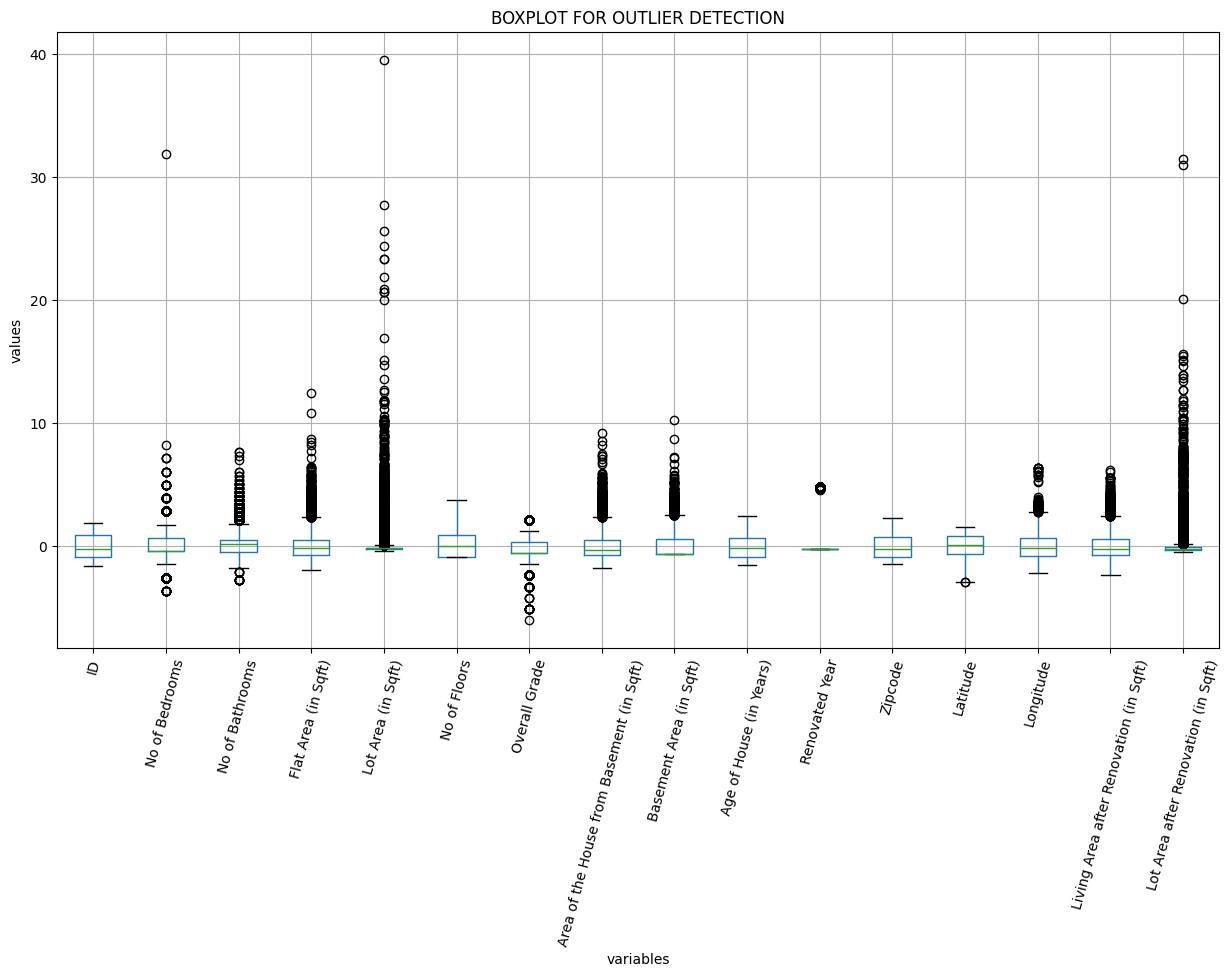

In [205]:
#boxplot
plt.figure(figsize=(15,8))
df_houseprice[num_cols].boxplot(rot=75) #rotation of below text
plt.title('BOXPLOT FOR OUTLIER DETECTION')
plt.xlabel('variables')
plt.ylabel('values')
plt.show()


In [206]:

#removal of outliers
df_houseprice = df_houseprice[(df_houseprice[col]>= lower_bound) & (df_houseprice[col] <= upper_bound)]
df_houseprice.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.886146,14 October 2017,221900.0,-0.398737,-1.447640,-0.979940,-0.228268,-0.915427,No,NaN,...,-0.564013,-0.734756,-0.658681,0.544898,-0.210128,1.870228,-0.352545,-0.306112,-0.943328,-0.260715
1,0.637511,14 December 2017,538000.0,-0.398737,0.175628,0.533757,-0.189832,0.936506,No,NaN,...,-0.564013,0.461025,0.245141,0.681079,4.746678,0.879629,1.161615,-0.746380,-0.432658,-0.187868
2,0.365444,15 February 2016,180000.0,-1.473959,-1.447640,-1.426426,-0.123244,-0.915427,No,NaN,...,-1.468651,-1.229979,-0.658681,1.293892,-0.210128,-0.933352,1.283585,-0.135686,1.070173,-0.172375
3,-0.727656,14 December 2017,604000.0,0.676485,1.149589,-0.130528,-0.243962,-0.915427,No,NaN,...,-0.564013,-0.891778,1.397515,0.204446,-0.210128,1.085225,-0.283260,-1.271861,-0.914147,-0.284522
4,-0.912881,15 February 2016,510000.0,-0.398737,-0.149026,-0.435445,-0.169600,-0.915427,No,NaN,...,0.340626,-0.130826,-0.658681,-0.544548,-0.210128,-0.073588,0.409587,1.199321,-0.272161,-0.192849


#Train-Test Split

##Define X and y

In [207]:
#Set aside the SalePrice column as the target variable.
# y = what we want to PREDICT
y = df_houseprice['Sale Price']

# X = all columns EXCEPT Sale Price
X = df_houseprice.drop(columns=['Sale Price'])

print("X shape:", X.shape)  # rows, 20 columns
print("y shape:", y.shape)  # rows, Sale Price only

X shape: (19419, 20)
y shape: (19419,)


##Split into 80% Train & 20% Test:

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

###Verify the Split

In [209]:
print("X_train:", X_train.shape) #80% of input columns
print("X_test:", X_test.shape) #20% of input columns
print("y_train:", y_train.shape) #80% of Sale Prices
print("y_test:", y_test.shape) #20% of Sale Prices

X_train: (15535, 20)
X_test: (3884, 20)
y_train: (15535,)
y_test: (3884,)


# Checking Data before Model Building

In [210]:
df_houseprice.dtypes

,0
ID,float64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [211]:
y_train

,Sale Price
10867,750000.0
6031,300000.0
9427,275000.0
12891,582000.0
7531,255000.0
...,...
12636,585000.0
13407,790000.0
6073,800000.0
979,427200.0


In [220]:
X_train

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
10867,-1.560682,15 May 2016,0.676485,-0.798333,-0.021628,-0.268105,0.010539,No,Twice,Fair,-0.564013,-0.251612,0.425906,1.736479,4.744188,0.468438,0.906850,-0.987817,-1.205959,-0.321147
6031,0.626178,15 January 2016,-0.398737,-1.447640,-0.642353,-0.190846,-0.915427,No,NaN,Fair,-0.564013,-0.360320,-0.658681,0.578943,-0.210128,0.879629,1.209249,-0.661167,-1.030872,-0.203946
9427,-0.476030,15 March 2016,-0.398737,-0.798333,-0.794812,-0.176360,-0.915427,No,NaN,Fair,-0.564013,-0.529420,-0.658681,0.408717,-0.210128,-0.353946,-0.574112,0.396897,-0.695288,-0.173181
12891,-0.974344,14 July 2017,1.751707,0.500282,0.762445,-0.066869,-0.915427,No,NaN,Good,0.340626,-0.239534,2.030191,0.102310,-0.210128,-1.344544,0.058112,0.609929,1.113945,-0.103959
7531,1.486426,15 March 2016,0.676485,0.500282,0.090538,-0.222667,0.936506,No,NaN,Fair,-0.564013,0.452570,-0.658681,-1.191407,-0.210128,-1.437997,-2.067342,-0.263505,-0.330524,-0.116046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12636,1.485764,14 December 2017,-0.398737,1.474243,1.056472,-0.058056,0.936506,No,NaN,Fair,0.340626,0.545575,1.171559,-0.646684,-0.210128,-1.251091,1.331219,-0.000765,1.551662,-0.014008
13407,0.729567,14 August 2017,0.676485,0.500282,0.174390,-0.155500,-0.915427,No,NaN,Excellent,0.340626,-0.384477,1.081177,-0.136006,-0.210128,-0.839900,0.736525,0.176763,0.326053,-0.143148
6073,-0.575436,15 May 2016,1.751707,0.500282,1.002023,-0.109724,-0.915427,No,NaN,Fair,0.340626,-0.348241,2.730653,0.170401,-0.210128,-1.381925,0.468046,0.056044,1.026401,-0.042209
979,-0.478047,15 March 2016,-0.398737,-1.447640,-1.143289,-0.161874,-0.915427,No,NaN,Good,-0.564013,-0.915936,-0.658681,0.272536,-0.210128,-0.410017,-0.170672,0.290380,-1.045463,-0.159996


# Model Building

In [213]:
# Check whether dataframe is all numerical
df_houseprice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19419 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         19419 non-null  float64
 1   Date House was Sold                        19419 non-null  object 
 2   Sale Price                                 19419 non-null  float64
 3   No of Bedrooms                             19419 non-null  float64
 4   No of Bathrooms                            19419 non-null  float64
 5   Flat Area (in Sqft)                        19419 non-null  float64
 6   Lot Area (in Sqft)                         19419 non-null  float64
 7   No of Floors                               19419 non-null  float64
 8   Waterfront View                            19419 non-null  object 
 9   No of Times Visited                        1766 non-null   object 
 10  Condition of the House     

In [214]:
#split into features and target
y = df_houseprice['Sale Price']                         #Target
X = df_houseprice.drop(columns = ['Sale Price'], axis=1)#Features

#split into test train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

In [215]:
y_test.head()

,Sale Price
15577,320900.0
12846,860000.0
997,553500.0
8322,360000.0
3276,456500.0


In [217]:
X_test

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
15577,-0.419191,14 July 2017,-0.398737,-0.149026,-0.337436,-0.189615,-0.915427,No,NaN,Good,0.340626,-0.022119,-0.658681,-0.646684,-0.210128,-0.877281,-1.092304,0.311683,0.836723,-0.203580
12846,-1.444893,14 December 2017,0.676485,1.474243,1.905885,-0.123123,0.936506,No,NaN,Fair,2.149903,2.466073,-0.658681,-1.021181,-0.210128,-0.054897,0.254418,1.241927,0.829428,-0.277050
997,-0.251486,14 August 2017,-1.473959,-1.447640,-1.339307,-0.308183,-0.915427,No,NaN,Fair,-0.564013,-1.133350,-0.658681,1.668389,-0.210128,0.505819,0.798592,-0.810290,-1.001691,-0.357772
8322,-1.090493,15 May 2016,-0.398737,-0.798333,-1.110619,-0.214217,-0.915427,No,NaN,Good,-0.564013,-0.879700,-0.658681,0.102310,-0.210128,0.748796,-0.195933,-0.405527,-1.264321,-0.270641
3276,-0.244739,15 January 2016,-0.398737,0.175628,0.011041,-0.143452,-0.915427,No,NaN,Fair,-0.564013,-0.396556,0.764839,-0.136006,-0.210128,-0.821209,1.251108,0.332987,-0.038712,-0.185157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17860,-0.347819,14 August 2017,0.676485,0.500282,0.239729,-0.101998,-0.915427,No,NaN,Good,-0.564013,-0.722678,1.849426,0.340627,-0.210128,-0.933352,1.256160,-0.199596,-0.038712,-0.086745
5285,-0.585330,15 March 2016,-0.398737,-0.473679,-0.609683,-0.178774,-0.915427,No,NaN,Fair,-0.564013,-1.169586,0.923008,0.068265,-0.210128,-0.821209,1.173163,-0.036270,-0.826604,-0.186586
0,0.886146,14 October 2017,-0.398737,-1.447640,-0.979940,-0.228268,-0.915427,No,NaN,Fair,-0.564013,-0.734756,-0.658681,0.544898,-0.210128,1.870228,-0.352545,-0.306112,-0.943328,-0.260715
15204,-0.258926,14 October 2017,0.676485,0.824935,2.395931,-0.058829,0.936506,No,NaN,Fair,1.245265,2.550623,0.199950,0.817259,4.789001,-1.381925,0.421856,-0.036270,2.339554,-0.003606


In [273]:
print(X_train.dtypes)

ID                                           float64
Date House was Sold                           object
No of Bedrooms                               float64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                              float64
Condition of the House                         int64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                      float64
Renovated Year                               float64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          f

In [274]:
# X_train fix
X_train['Date House was Sold'] = pd.to_datetime(X_train['Date House was Sold'])
X_train['Sale_year'] = X_train['Date House was Sold'].dt.year
X_train['month'] = X_train['Date House was Sold'].dt.month
X_train['day'] = X_train['Date House was Sold'].dt.day
X_train = X_train.drop(columns=['Date House was Sold'])

In [275]:
# X_test fix (same steps)
X_test['Date House was Sold'] = pd.to_datetime(X_test['Date House was Sold'])
X_test['Sale_year'] = X_test['Date House was Sold'].dt.year
X_test['month'] = X_test['Date House was Sold'].dt.month
X_test['day'] = X_test['Date House was Sold'].dt.day
X_test = X_test.drop(columns=['Date House was Sold'])

In [276]:
print(X_train.dtypes)

ID                                           float64
No of Bedrooms                               float64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                              float64
Condition of the House                         int64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                      float64
Renovated Year                               float64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          float64
Sale_year                                     

In [277]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [260]:
X_train["Waterfront View"] = X_train["Waterfront View"].map({"No": 0,"Yes": 1})
X_test["Waterfront View"] = X_test["Waterfront View"].map({"No": 0,"Yes": 1})

In [261]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train["Condition of the House"] = le.fit_transform(X_train["Condition of the House"].astype(str))

X_test["Condition of the House"] = le.transform(X_test["Condition of the House"].astype(str))

In [262]:
print(X_train.select_dtypes(include="object").columns)

Index(['Date House was Sold'], dtype='object')


# Linear Regression

In [278]:
#create model object
lin_reg = LinearRegression()
#train the model
lin_reg.fit(X_train,y_train)
#make prediction using the model
y_pred = lin_reg.predict(X_test)
#evaluate the model
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
print('mean_absolute_error:',mae)
print('mean_squared_error:',mse)
print('root_mean_squared_error:',rmse)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

#Logistic Regession

In [250]:
# create model object
Log_reg = LogisticRegression()

#train the model
Log_reg.fit(X_train, y_train)

#make predictions using the model
y_pred_Log_reg = Log_reg.predict(X_test)

#evaluate the model:
acc_log_reg = accuracy_score(y_test, y_pred_Log_reg)

print("Accuracy of Logistic Regression:",acc_log_reg)

ValueError: could not convert string to float: '15 May 2016'

# k-NN

In [251]:
# build the model object
kNN = KNeighborsClassifier(n_neighbors= 4)

# Train the model
kNN.fit(X_train, y_train)
# make predictions using the model
y_pred_kNN = kNN.predict(X_test)
# evaluate the model performance
acc_kNN = accuracy_score(y_test, y_pred_kNN)

print('Accuracy comparison')
print('**********')
print('Accuracy of logistic regression:',acc_log_reg)
print('Accuracy of KNN model:',acc_kNN)

ValueError: could not convert string to float: '15 May 2016'

## Decision Tree

In [252]:
# build the model object
dT_model = DecisionTreeClassifier()
#train the model
dT_model.fit(X_train, y_train)
# make predictions using the model
y_pred_DT =dT_model.predict(X_test)
#evaluate the model performance
acc_DT =accuracy_score(y_test,y_pred_DT)
print("Accuracy:",acc_DT)

ValueError: could not convert string to float: '15 May 2016'

## Random Forest

In [253]:
# build the model object
rF_model = RandomForestClassifier()
# OR Model
#ran_model = RandomForestClassifier(min_samples_split=2, random_state=33)
#train the model
rF_model.fit(X_train, y_train)
# make predictions using the model
y_pred_RF =rF_model.predict(X_test)
#evaluate the model performance
acc_RF =accuracy_score(y_test,y_pred_RF)
print("Accuracy of Random Forest Model:",acc_RF)

ValueError: could not convert string to float: '15 May 2016'